In [1]:
# ═══════════════════════════════════════════════════════
# CELDA 1: Instalación e Imports
# ═══════════════════════════════════════════════════════
!pip install numpy scikit-learn tensorflow matplotlib seaborn -q

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, top_k_accuracy_score)
from tensorflow.keras.utils import to_categorical

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ═══════════════════════════════════════════════════════
# CELDA 2: Carga del Dataset
# ═══════════════════════════════════════════════════════
import gdown

if not os.path.exists("/content/X.npy"):
    gdown.download(
        "https://drive.google.com/uc?id=1KX-okzn_Oo8Mk_3FOmO-siN6Ok6X_iJv",
        "/content/X.npy", quiet=False
    )
if not os.path.exists("/content/Y.npy"):
    gdown.download(
        "https://drive.google.com/uc?id=1bGphucb5oTgLkYT2e9UB4ToaapvhKhhw",
        "/content/Y.npy", quiet=False
    )

X = np.load("/content/X.npy", mmap_mode='r')
Y_raw = np.load("/content/Y.npy", allow_pickle=True)

print("Shape X:", X.shape)
print("Shape Y_raw:", Y_raw.shape, "| Dtype:", Y_raw.dtype)

# MobileNetV2 espera imágenes RGB de 3 canales
assert X.ndim == 4 and X.shape[3] == 3, "MobileNetV2 requiere imágenes RGB (canal=3)"
print("✅ Formato de imagen compatible con MobileNetV2")

Downloading...
From (original): https://drive.google.com/uc?id=1KX-okzn_Oo8Mk_3FOmO-siN6Ok6X_iJv
From (redirected): https://drive.google.com/uc?id=1KX-okzn_Oo8Mk_3FOmO-siN6Ok6X_iJv&confirm=t&uuid=d723b8e0-1c50-4694-acb4-329d55c0ce72
To: /content/X.npy
100%|██████████| 4.48G/4.48G [01:01<00:00, 73.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1bGphucb5oTgLkYT2e9UB4ToaapvhKhhw
To: /content/Y.npy
100%|██████████| 1.55M/1.55M [00:00<00:00, 129MB/s]

Shape X: (22801, 128, 128, 3)
Shape Y_raw: (22801, 1) | Dtype: <U17
✅ Formato de imagen compatible con MobileNetV2


In [3]:
# ═══════════════════════════════════════════════════════
# CELDA 3: Preprocesamiento — Encoding + Split 70/15/15
# ═══════════════════════════════════════════════════════
num_samples  = X.shape[0]
img_height   = X.shape[1]   # 128
img_width    = X.shape[2]   # 128
num_channels = X.shape[3]   # 3

# Encode labels
y_str       = Y_raw.reshape(-1)
le          = LabelEncoder()
y_int       = le.fit_transform(y_str)
Y           = to_categorical(y_int)
num_classes = Y.shape[1]
class_names = list(le.classes_)

print(f"Imágenes : {num_samples} | Shape: {img_height}x{img_width}x{num_channels}")
print(f"Clases ({num_classes}): {class_names}")

# Split estratificado 70/15/15
idx = np.arange(num_samples)
idx_tv, idx_test, Y_tv, Y_test, y_tv_cls, y_test_cls = train_test_split(
    idx, Y, y_int, test_size=0.15, random_state=42, stratify=y_int
)
idx_train, idx_val, Y_train, Y_val, y_train_cls, y_val_cls = train_test_split(
    idx_tv, Y_tv, y_tv_cls, test_size=0.176, random_state=42, stratify=y_tv_cls
)

print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

Imágenes : 22801 | Shape: 128x128x3
Clases (27): [np.str_('0'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_('NULL'), np.str_('a'), np.str_('b'), np.str_('bye'), np.str_('c'), np.str_('d'), np.str_('e'), np.str_('good'), np.str_('good morning'), np.str_('hello'), np.str_('little bit'), np.str_('no'), np.str_('pardon'), np.str_('please'), np.str_('project'), np.str_('whats up'), np.str_('yes')]
Train: 15969 | Val: 3411 | Test: 3421


In [4]:
# ═══════════════════════════════════════════════════════
# CELDA 4: Generador — normalización específica de MobileNetV2
# ═══════════════════════════════════════════════════════
# IMPORTANTE: MobileNetV2 NO usa [0,1] sino [-1, 1]
# Se usa tf.keras.applications.mobilenet_v2.preprocess_input

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

class TransferBatchGenerator(keras.utils.Sequence):
    def __init__(self, X_mmap, indices, labels, batch_size=32, augment=False):
        self.X       = X_mmap
        self.idx     = indices
        self.labels  = labels
        self.bs      = batch_size
        self.augment = augment

    def __len__(self):
        return int(np.ceil(len(self.idx) / self.bs))

    def __getitem__(self, i):
        batch_idx = self.idx[i*self.bs:(i+1)*self.bs]
        imgs = np.array(self.X[batch_idx], dtype=np.float32)

        # Escalar a [0,255] si ya estaba normalizado
        if imgs.max() <= 1.5:
            imgs = imgs * 255.0

        # Preprocesamiento oficial de MobileNetV2 → escala a [-1, 1]
        imgs = mobilenet_preprocess(imgs)

        if self.augment:
            imgs = self._augment(imgs)

        return imgs, self.labels[i*self.bs:(i+1)*self.bs]

    def _augment(self, imgs):
        # Flip horizontal
        mask = np.random.rand(len(imgs)) > 0.5
        imgs[mask] = imgs[mask, :, ::-1, :]
        # Brillo leve (en escala [-1,1] usamos ±0.1)
        brightness = np.random.uniform(-0.1, 0.1, (len(imgs), 1, 1, 1))
        imgs = np.clip(imgs + brightness, -1, 1)
        return imgs

BATCH_SIZE = 32
train_gen = TransferBatchGenerator(X, idx_train, Y_train, BATCH_SIZE, augment=True)
val_gen   = TransferBatchGenerator(X, idx_val,   Y_val,   BATCH_SIZE, augment=False)
test_gen  = TransferBatchGenerator(X, idx_test,  Y_test,  BATCH_SIZE, augment=False)

print(f"Batches — Train: {len(train_gen)} | Val: {len(val_gen)} | Test: {len(test_gen)}")

Batches — Train: 500 | Val: 107 | Test: 107


In [5]:
# ═══════════════════════════════════════════════════════
# CELDA 5: Selección de métricas
# ═══════════════════════════════════════════════════════
# ─── JUSTIFICACIÓN ───────────────────────────────────
# Problema: Clasificación multiclase de señas de mano (27 clases)
# Arquitectura: Transfer Learning con MobileNetV2
#
# MÉTRICA DE OPTIMIZACIÓN:
#   → categorical_crossentropy
#     Misma razón que antes: distribución predicha vs one-hot real.
#     Con Transfer Learning es más estable porque el backbone ya
#     genera features significativos desde la época 1.
#
# MÉTRICA DE SATISFACCIÓN:
#   → Primary:   Top-1 Accuracy   (¿acierta la clase exacta?)
#   → Secondary: Top-3 Accuracy   (¿está la real entre las 3 primeras?)
#   → Additional: Macro F1-Score  (penaliza clases desbalanceadas)
#
# CRITERIO DE ÉXITO (más exigente que CNN from scratch):
#   Test Accuracy >= 0.95  → aceptable (Transfer Learning debe mejorar la CNN base)
#   Test Accuracy >= 0.98  → robusto
#
# Nota: tu CNN from scratch ya alcanzó ~0.9845, así que el umbral
#       robusto de Transfer Learning se eleva a 0.98.
# ──────────────────────────────────────────────────────

OPTIMIZER_METRIC     = "categorical_crossentropy"
SATISFACTION_METRIC  = "accuracy"
THRESHOLD_ACCEPTABLE = 0.95
THRESHOLD_ROBUST     = 0.98

print("Métrica de optimización :", OPTIMIZER_METRIC)
print("Umbral aceptable        :", THRESHOLD_ACCEPTABLE,
      "(tu CNN base ya logró ~0.9845 → Transfer Learning debe superarla)")
print("Umbral robusto          :", THRESHOLD_ROBUST)

Métrica de optimización : categorical_crossentropy
Umbral aceptable        : 0.95 (tu CNN base ya logró ~0.9845 → Transfer Learning debe superarla)
Umbral robusto          : 0.98


In [23]:
# ═══════════════════════════════════════════════════════
# CELDA 6: Modelo con MobileNetV2 (Transfer Learning)
# ═══════════════════════════════════════════════════════
# ─── ESTRATEGIA DE 2 FASES ───────────────────────────
# FASE 1 — Feature Extraction:
#   El backbone MobileNetV2 está CONGELADO (include_top=False).
#   Solo se entrenan las capas Dense que agregamos encima.
#   LR alta (1e-3). Pocas épocas (15-20).
#   Objetivo: que las nuevas capas Dense aprendan a clasificar
#   usando las features de ImageNet como punto de partida.
#
# FASE 2 — Fine-Tuning:
#   Se descongelan las últimas N capas del backbone.
#   LR muy baja (1e-5) para no destruir los pesos pre-entrenados.
#   Más épocas. Objetivo: adaptar los filtros profundos a señas de mano.
# ──────────────────────────────────────────────────────

def build_transfer_model(img_h, img_w, num_classes):
    # Cargar MobileNetV2 SIN las capas de clasificación de ImageNet
    base_model = MobileNetV2(
        input_shape=(img_h, img_w, 3),
        include_top=False,      # sin las Dense finales de ImageNet
        weights='imagenet'      # pesos pre-entrenados en 1.2M imágenes
    )
    base_model.trainable = False   # FASE 1: congelar todo el backbone

    inputs  = keras.Input(shape=(img_h, img_w, 3), name="input_img")
    x       = base_model(inputs, training=False)   # training=False → BN en inferencia
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.6)(x)  # Se aumenta dropout de 0.4 a 0.5 para combatir varianza
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name="HandSign_MobileNetV2")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=OPTIMIZER_METRIC,
        metrics=[SATISFACTION_METRIC]
    )
    return model, base_model

model_tl, base_model = build_transfer_model(img_height, img_width, num_classes)
model_tl.summary()

# Contar parámetros
total     = model_tl.count_params()
trainable = sum([tf.size(w).numpy() for w in model_tl.trainable_weights])
frozen    = total - trainable
print(f"\nParámetros totales    : {total:,}")
print(f"Entrenables (Fase 1)  : {trainable:,}  ← solo las Dense nuevas")
print(f"Congelados (backbone) : {frozen:,}")

Model: "HandSign_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)          │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 27)             │         6,939 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,859 (9.89 MB)

 Trainable params: 334,875 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Parámetros totales    : 2,592,859
Entrenables (Fase 1)  : 334,875  ← solo las Dense nuevas
Congelados (backbone) : 2,257,984


In [25]:
# ═══════════════════════════════════════════════════════
# CELDA 7: FASE 1 — Entrenar solo el clasificador (backbone congelado)
# ═══════════════════════════════════════════════════════
print("=" * 55)
print("FASE 1: Feature Extraction (backbone MobileNetV2 congelado)")
print("=" * 55)

callbacks_fase1 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "/content/best_tl_fase1.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history_fase1 = model_tl.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks_fase1,
    verbose=1
)

print(f"\nFase 1 completada.")
print(f"Mejor val_accuracy Fase 1: {max(history_fase1.history['val_accuracy']):.4f}")

FASE 1: Feature Extraction (backbone MobileNetV2 congelado)
Epoch 1/10
498/500 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.2041 - loss: 2.7512
Epoch 1: val_accuracy improved from None to 0.58399, saving model to /content/best_tl_fase1.keras

Epoch 1: finished saving model to /content/best_tl_fase1.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 72ms/step - accuracy: 0.3157 - loss: 2.2322 - val_accuracy: 0.5840 - val_loss: 1.2633 - learning_rate: 0.0010
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4830 - loss: 1.5377
Epoch 2: val_accuracy improved from 0.58399 to 0.67693, saving model to /content/best_tl_fase1.keras

Epoch 2: finished saving model to /content/best_tl_fase1.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.5057 - loss: 1.4733 - val_accuracy: 0.6769 - val_loss: 1.0108 - learning_rate: 0.0010
Epoch 3/10
498/500 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5533 - loss: 1.3091
Epoch 3: val_accuracy improved from 0.67693 to 0.69598, saving mod

In [30]:
# ═══════════════════════════════════════════════════════
# CELDA 8: FASE 2 — Fine-Tuning (descongelar últimas capas)
# ═══════════════════════════════════════════════════════
print("=" * 55)
print("FASE 2: Fine-Tuning (descongelar últimas 10 capas)")
print("=" * 55)

# Descongelar solo las últimas 10 capas del backbone
base_model.trainable = True
FINE_TUNE_FROM = len(base_model.layers) - 10

for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= FINE_TUNE_FROM)

# Recompilar con LR MUY baja para no destruir pesos pre-entrenados
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=OPTIMIZER_METRIC,
    metrics=[SATISFACTION_METRIC]
)

trainable_fase2 = sum([tf.size(w).numpy() for w in model_tl.trainable_weights])
print(f"Capas descongeladas   : {sum(1 for l in base_model.layers if l.trainable)}")
print(f"Parámetros entrenables: {trainable_fase2:,}")

callbacks_fase2 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        "/content/best_tl_fase2.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history_fase2 = model_tl.fit(
    train_gen,
    epochs=35,
    validation_data=val_gen,
    callbacks=callbacks_fase2,
    verbose=1
)

print(f"\nFase 2 completada.")
print(f"Mejor val_accuracy Fase 2: {max(history_fase2.history['val_accuracy']):.4f}")

FASE 2: Fine-Tuning (descongelar últimas 10 capas)
Capas descongeladas   : 10
Parámetros entrenables: 1,067,355
Epoch 1/35
497/500 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8950 - loss: 0.3064
Epoch 1: val_accuracy improved from None to 0.86456, saving model to /content/best_tl_fase2.keras

Epoch 1: finished saving model to /content/best_tl_fase2.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 57ms/step - accuracy: 0.8976 - loss: 0.3032 - val_accuracy: 0.8646 - val_loss: 0.3958 - learning_rate: 1.0000e-05
Epoch 2/35
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8962 - loss: 0.2992
Epoch 2: val_accuracy improved from 0.86456 to 0.86602, saving model to /content/best_tl_fase2.keras

Epoch 2: finished saving model to /content/best_tl_fase2.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.8977 - loss: 0.2963 - val_accuracy: 0.8660 - val_loss: 0.3878 - learning_rate: 1.0000e-05
Epoch 3/35
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9014 - loss: 0.2881
Epoch 

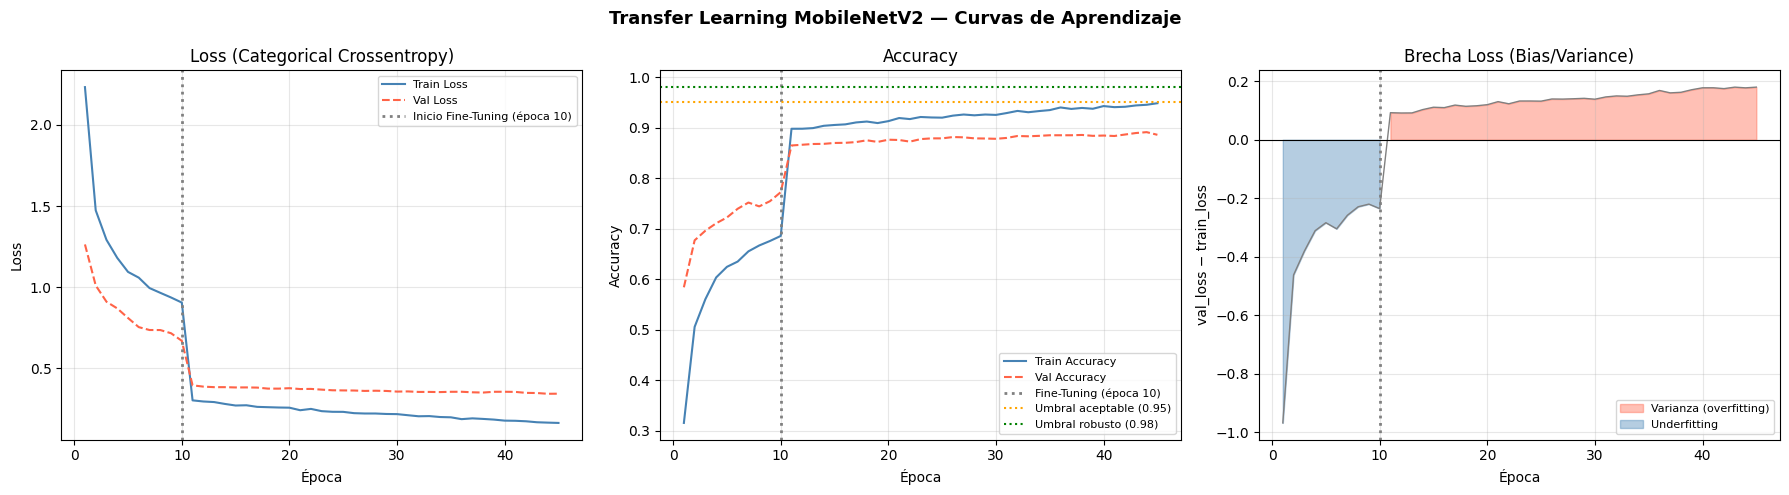


DIAGNÓSTICO BIAS / VARIANCE
Train Loss final : 0.1642
Val   Loss final : 0.3442
Brecha (gap)     : 0.1801
Mejor Val Acc    : 0.8909

✅ BALANCE OK: Transfer Learning bien calibrado.


In [31]:
# ═══════════════════════════════════════════════════════
# CELDA 9: Curvas de aprendizaje Fase 1 + Fase 2 + Bias/Variance
# ═══════════════════════════════════════════════════════
# Concatenar historial de ambas fases
h1 = history_fase1.history
h2 = history_fase2.history

all_loss     = h1['loss']     + h2['loss']
all_val_loss = h1['val_loss'] + h2['val_loss']
all_acc      = h1['accuracy'] + h2['accuracy']
all_val_acc  = h1['val_accuracy'] + h2['val_accuracy']

epochs_total = range(1, len(all_loss) + 1)
fase1_end    = len(h1['loss'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Transfer Learning MobileNetV2 — Curvas de Aprendizaje", fontsize=13, fontweight='bold')

# ── Loss ──
axes[0].plot(epochs_total, all_loss,     label='Train Loss',  color='steelblue')
axes[0].plot(epochs_total, all_val_loss, label='Val Loss',    color='tomato', linestyle='--')
axes[0].axvline(fase1_end, color='gray', linestyle=':', linewidth=2, label=f'Inicio Fine-Tuning (época {fase1_end})')
axes[0].set_title('Loss (Categorical Crossentropy)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# ── Accuracy ──
axes[1].plot(epochs_total, all_acc,     label='Train Accuracy', color='steelblue')
axes[1].plot(epochs_total, all_val_acc, label='Val Accuracy',   color='tomato', linestyle='--')
axes[1].axvline(fase1_end, color='gray', linestyle=':', linewidth=2, label=f'Fine-Tuning (época {fase1_end})')
axes[1].axhline(THRESHOLD_ACCEPTABLE, color='orange', linestyle=':', label=f'Umbral aceptable ({THRESHOLD_ACCEPTABLE})')
axes[1].axhline(THRESHOLD_ROBUST,     color='green',  linestyle=':', label=f'Umbral robusto ({THRESHOLD_ROBUST})')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# ── Brecha Bias/Variance ──
gap = np.array(all_val_loss) - np.array(all_loss)
axes[2].fill_between(epochs_total, gap, 0, where=(gap > 0),
                     alpha=0.4, color='tomato',    label='Varianza (overfitting)')
axes[2].fill_between(epochs_total, gap, 0, where=(gap < 0),
                     alpha=0.4, color='steelblue', label='Underfitting')
axes[2].axvline(fase1_end, color='gray', linestyle=':', linewidth=2)
axes[2].plot(epochs_total, gap, color='gray', linewidth=1)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Brecha Loss (Bias/Variance)')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('val_loss − train_loss')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/curvas_transfer_learning.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Diagnóstico automático ──
final_train_loss = all_loss[-1]
final_val_loss   = all_val_loss[-1]
final_gap        = final_val_loss - final_train_loss
best_val_acc     = max(all_val_acc)

print("\n" + "="*50)
print("DIAGNÓSTICO BIAS / VARIANCE")
print("="*50)
print(f"Train Loss final : {final_train_loss:.4f}")
print(f"Val   Loss final : {final_val_loss:.4f}")
print(f"Brecha (gap)     : {final_gap:.4f}")
print(f"Mejor Val Acc    : {best_val_acc:.4f}")

if final_train_loss > 0.25:
    print("\n⚠️  HIGH BIAS: La red no aprovecha bien el pre-entrenamiento.")
    print("   → Descongelá más capas o aumenta épocas de Fase 2.")
elif final_gap > 0.2:
    print("\n⚠️  HIGH VARIANCE: Overfitting. Fine-Tuning demasiado agresivo.")
    print("   → Reducí capas descongeladas o aumentá Dropout/augmentation.")
else:
    print("\n✅ BALANCE OK: Transfer Learning bien calibrado.")

In [32]:
# ═══════════════════════════════════════════════════════
# CELDA 10: Evaluación en Test Set
# ═══════════════════════════════════════════════════════
from sklearn.metrics import accuracy_score, classification_report, top_k_accuracy_score

# ── Predicciones ──
Y_pred_proba = model_tl.predict(test_gen, verbose=0)
Y_pred_cls   = np.argmax(Y_pred_proba, axis=1)

# Extraer etiquetas reales del generador de forma segura
Y_true_list = []
for i in range(len(test_gen)):
    _, batch_y = test_gen[i]
    Y_true_list.append(batch_y)
Y_true_cls = np.concatenate([np.argmax(b, axis=1) for b in Y_true_list])[:len(Y_pred_cls)]

# ── Métricas (todas desde sklearn para evitar el bug de nombres de Keras) ──
test_acc = accuracy_score(Y_true_cls, Y_pred_cls)
top3_acc = top_k_accuracy_score(Y_true_cls, Y_pred_proba, k=3)
macro_f1 = f1_score(Y_true_cls, Y_pred_cls, average='macro', zero_division=0)

print("="*55)
print("EVALUACIÓN EN TEST SET — Transfer Learning")
print("="*55)
print(f"  Top-1 Accuracy   : {test_acc:.4f}")
print(f"  Top-3 Accuracy   : {top3_acc:.4f}")
print(f"  Macro F1-Score   : {macro_f1:.4f}")

print()
if test_acc >= THRESHOLD_ROBUST:
    print(f"✅ MODELO ROBUSTO — supera umbral robusto ({THRESHOLD_ROBUST})")
elif test_acc >= THRESHOLD_ACCEPTABLE:
    print(f"🟡 MODELO ACEPTABLE — supera umbral aceptable ({THRESHOLD_ACCEPTABLE})")
else:
    print(f"❌ MODELO INSUFICIENTE — no supera umbral aceptable ({THRESHOLD_ACCEPTABLE})")

print("\nReporte de clasificación:")
print(classification_report(Y_true_cls, Y_pred_cls, target_names=class_names))

EVALUACIÓN EN TEST SET — Transfer Learning
  Top-1 Accuracy   : 0.8790
  Top-3 Accuracy   : 0.9769
  Macro F1-Score   : 0.8814

❌ MODELO INSUFICIENTE — no supera umbral aceptable (0.95)

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       130
           1       0.90      0.87      0.89       129
           2       0.80      0.85      0.82       130
           3       0.83      0.77      0.80       130
           4       0.80      0.79      0.80       129
           5       0.92      0.92      0.92       130
           6       0.77      0.72      0.74       130
           7       0.58      0.65      0.61       130
           8       0.65      0.62      0.63       130
           9       0.79      0.77      0.78       130
        NULL       1.00      0.96      0.98        47
           a       0.93      0.88      0.90       129
           b       0.93      0.96      0.94       130
         bye       0.94      0

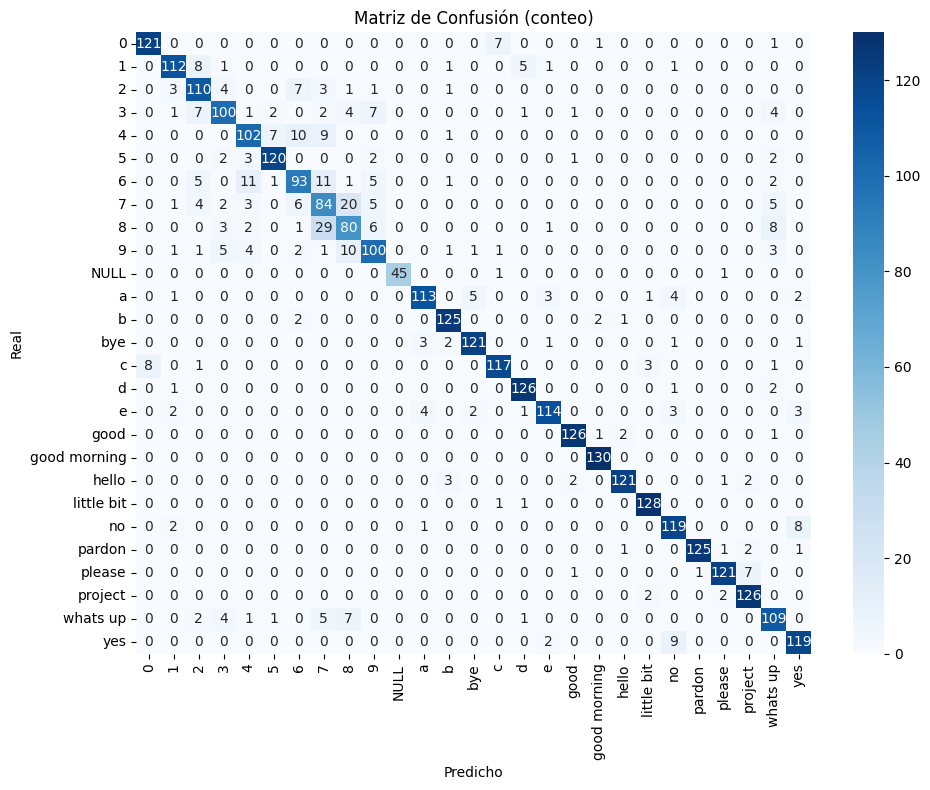

In [33]:
# ═══════════════════════════════════════════════════════
# CELDA 11: Matriz de Confusión
# ═══════════════════════════════════════════════════════
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_true_cls, Y_pred_cls)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)

ax.set_title('Matriz de Confusión (conteo)')
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')

plt.tight_layout()
plt.savefig('/content/confusion_tl.png', dpi=150, bbox_inches='tight')
plt.show()

Total errores: 414 / 3421 (12.1%)
Confianza media en errores  : 0.667
Errores con confianza > 0.80: 121

Clases con mayor tasa de error:
Clase             Error Rate   N muestras
----------------------------------------
8                     0.385          130 ⚠️
7                     0.354          130 ⚠️
6                     0.285          130 ⚠️
3                     0.231          130 ⚠️
9                     0.231          130 ⚠️
4                     0.209          129 ⚠️
whats up              0.162          130 ⚠️
2                     0.154          130 ⚠️
1                     0.132          129 ⚠️
a                     0.124          129 ⚠️


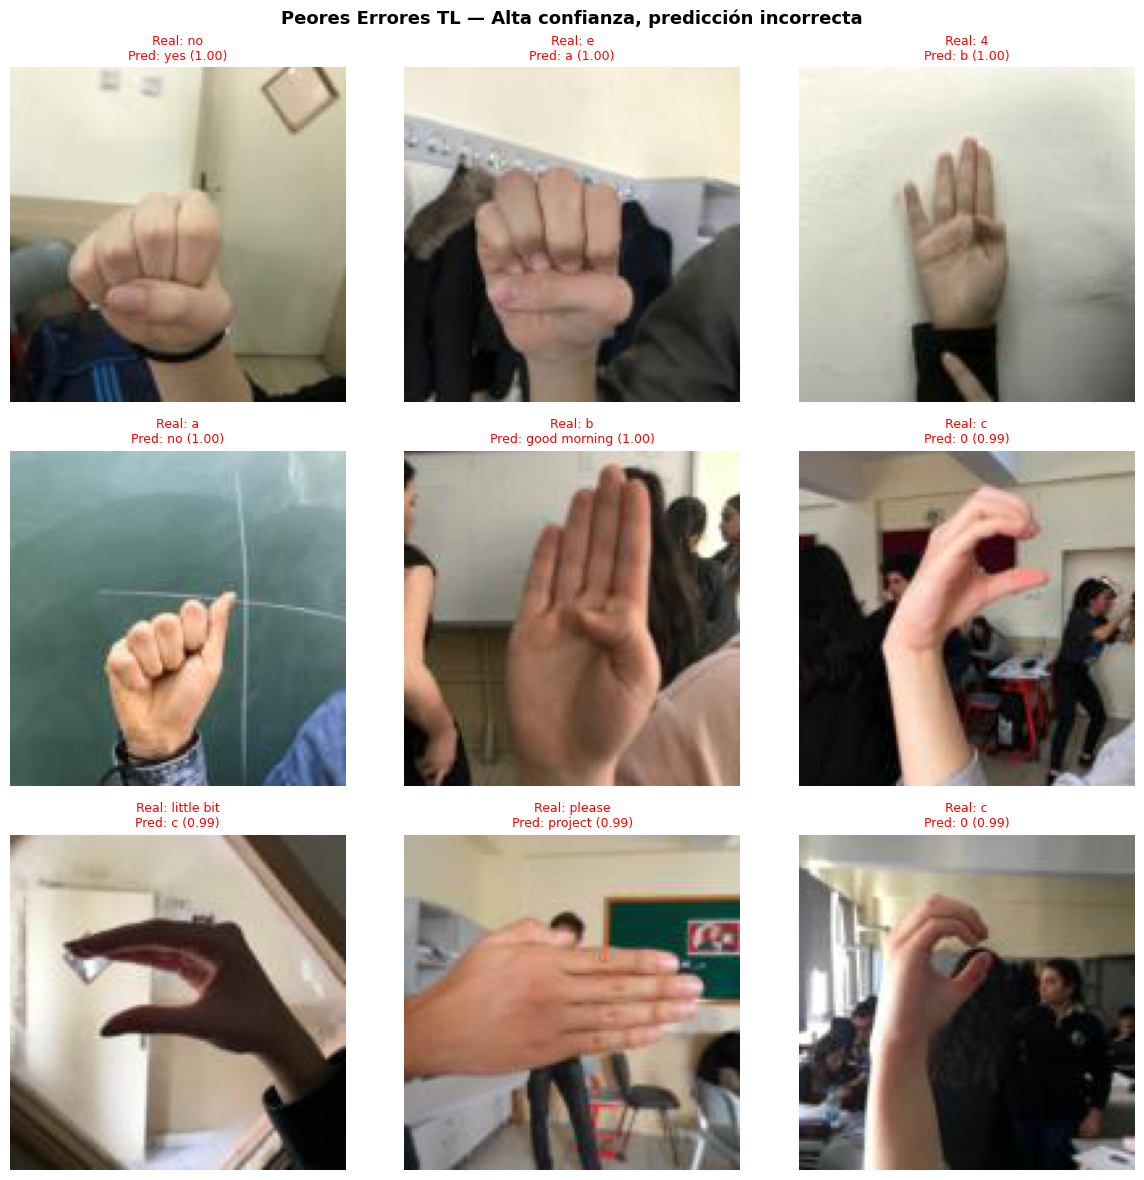

In [34]:
# ═══════════════════════════════════════════════════════
# CELDA 12: Análisis de Errores
# ═══════════════════════════════════════════════════════
errors_mask       = (Y_pred_cls != Y_true_cls)
error_indices     = np.where(errors_mask)[0]
error_confidences = Y_pred_proba[error_indices].max(axis=1)

print(f"Total errores: {len(error_indices)} / {len(Y_true_cls)} "
      f"({100*len(error_indices)/len(Y_true_cls):.1f}%)")
print(f"Confianza media en errores  : {error_confidences.mean():.3f}")

high_conf_errors = error_indices[error_confidences > 0.80]
print(f"Errores con confianza > 0.80: {len(high_conf_errors)}")

# Clases con mayor tasa de error
per_class_errors = []
for c in range(num_classes):
    mask_c = (Y_true_cls == c)
    if mask_c.sum() == 0:
        continue
    error_rate = (Y_pred_cls[mask_c] != c).mean()
    per_class_errors.append((class_names[c], error_rate, mask_c.sum()))

per_class_errors.sort(key=lambda x: -x[1])
print("\nClases con mayor tasa de error:")
print(f"{'Clase':<15} {'Error Rate':>12} {'N muestras':>12}")
print("-" * 40)
for cls, rate, n in per_class_errors[:10]:
    flag = " ⚠️" if rate > 0.10 else ""
    print(f"{cls:<15} {rate:>11.3f} {n:>12}{flag}")

# Visualizar 9 peores errores (alta confianza, predicción incorrecta)
if len(high_conf_errors) > 0:
    sorted_errors = high_conf_errors[np.argsort(-error_confidences[error_confidences > 0.80])]
    n_show = min(9, len(sorted_errors))

    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.suptitle("Peores Errores TL — Alta confianza, predicción incorrecta",
                 fontsize=13, fontweight='bold')

    for i, err_pos in enumerate(sorted_errors[:n_show]):
        real_data_idx = idx_test[err_pos]
        img = np.array(X[real_data_idx], dtype=np.float32)
        if img.max() <= 1.5:
            img_vis = img
        else:
            img_vis = img / 255.0

        true_label = class_names[Y_true_cls[err_pos]]
        pred_label = class_names[Y_pred_cls[err_pos]]
        conf       = Y_pred_proba[err_pos, Y_pred_cls[err_pos]]

        ax = axes[i // 3][i % 3]
        ax.imshow(img_vis.squeeze(), cmap='gray' if img_vis.ndim == 2 or img_vis.shape[-1] == 1 else None)
        ax.axis('off')
        ax.set_title(f"Real: {true_label}\nPred: {pred_label} ({conf:.2f})",
                     color='red', fontsize=9)

    plt.tight_layout()
    plt.savefig('/content/errores_tl.png', dpi=150, bbox_inches='tight')
    plt.show()

In [35]:
# ═══════════════════════════════════════════════════════
# CELDA 13: Resumen Final + Comparación con CNN base
# ═══════════════════════════════════════════════════════
gap_final = all_val_loss[-1] - all_loss[-1]
if abs(gap_final) < 0.1:
    bv_diag = "✅ Bien balanceado"
elif gap_final > 0.1:
    bv_diag = "⚠️  Tendencia a overfitting (alta varianza)"
else:
    bv_diag = "⚠️  Tendencia a underfitting (alto bias)"

CNN_BASE_ACC = 0.9845   # resultado de tu CNN from scratch

print("="*60)
print("    RESUMEN FINAL — TRANSFER LEARNING MobileNetV2")
print("="*60)
print(f"  Backbone           : MobileNetV2 (pre-entrenado ImageNet)")
print(f"  Estrategia         : Fase1 (congelado) → Fase2 (fine-tuning)")
print(f"  Capas descongeladas: últimas 30 del backbone")
print(f"  Optimizador Fase 1 : Adam (lr=1e-3)")
print(f"  Optimizador Fase 2 : Adam (lr=1e-5)")
print(f"  Loss (optimiz.)    : {OPTIMIZER_METRIC}")
print(f"  Clases             : {num_classes}")
print(f"  Train samples      : {len(idx_train)}")
print(f"  Test samples       : {len(idx_test)}")
print("-"*60)
print(f"  Test Accuracy      : {test_acc:.4f}  (umbral: {THRESHOLD_ACCEPTABLE})")
print(f"  Top-3 Accuracy     : {top3_acc:.4f}")
print(f"  Macro F1-Score     : {macro_f1:.4f}")
print(f"  Total errores      : {len(error_indices)} ({100*len(error_indices)/len(Y_true_cls):.1f}%)")
print("-"*60)
print(f"  Train Loss final   : {all_loss[-1]:.4f}")
print(f"  Val   Loss final   : {all_val_loss[-1]:.4f}")
print(f"  Bias/Variance      : {bv_diag}")
print("-"*60)
print("  COMPARACIÓN CNN from scratch vs Transfer Learning:")
print(f"    CNN base         : {CNN_BASE_ACC:.4f}")
print(f"    Transfer Learning: {test_acc:.4f}  ", end="")
if test_acc > CNN_BASE_ACC:
    print(f"(+{test_acc - CNN_BASE_ACC:.4f} ✅ mejora)")
else:
    print(f"({test_acc - CNN_BASE_ACC:.4f} — CNN base fue mejor en este caso)")
print("="*60)

    RESUMEN FINAL — TRANSFER LEARNING MobileNetV2
  Backbone           : MobileNetV2 (pre-entrenado ImageNet)
  Estrategia         : Fase1 (congelado) → Fase2 (fine-tuning)
  Capas descongeladas: últimas 30 del backbone
  Optimizador Fase 1 : Adam (lr=1e-3)
  Optimizador Fase 2 : Adam (lr=1e-5)
  Loss (optimiz.)    : categorical_crossentropy
  Clases             : 27
  Train samples      : 15969
  Test samples       : 3421
------------------------------------------------------------
  Test Accuracy      : 0.8790  (umbral: 0.95)
  Top-3 Accuracy     : 0.9769
  Macro F1-Score     : 0.8814
  Total errores      : 414 (12.1%)
------------------------------------------------------------
  Train Loss final   : 0.1642
  Val   Loss final   : 0.3442
  Bias/Variance      : ⚠️  Tendencia a overfitting (alta varianza)
------------------------------------------------------------
  COMPARACIÓN CNN from scratch vs Transfer Learning:
    CNN base         : 0.9845
    Transfer Learning: 0.8790  (-0.1055